In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
#gives me 2 decimal for every float
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.options.display.max_rows = 1000
pd.set_option("display.max_colwidth", 100)

# Importing CSVs

In [128]:
url = 'https://drive.google.com/file/d/1IAxyQZvZrMuRwhzlrtE004QpZb-Cg_YS/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


product_df = pd.read_csv(path)

In [129]:
url = 'https://drive.google.com/file/d/1u-p2lcwrKWtCoNId8ExV8HUP24ZKb7dM/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


order_df = pd.read_csv(path)

In [130]:
url = 'https://drive.google.com/file/d/1MvYFrNjNbdG58WHklDWd3oVKXKlX5YBU/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


orderline_df = pd.read_csv(path)

In [131]:
url = 'https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


brands_df = pd.read_csv(path)

In [132]:
orderline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53210 entries, 0 to 53209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               53210 non-null  int64  
 1   order_id         53210 non-null  int64  
 2   quantity         53210 non-null  int64  
 3   sku              53210 non-null  object 
 4   unit_price       53210 non-null  float64
 5   date             53210 non-null  object 
 6   unit_price_paid  53210 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 2.8+ MB


In [133]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40971 entries, 0 to 40970
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      40971 non-null  int64  
 1   created_date  40971 non-null  object 
 2   total_paid    40971 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 960.4+ KB


In [134]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9940 entries, 0 to 9939
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sku     9940 non-null   object 
 1   name    9940 non-null   object 
 2   desc    9940 non-null   object 
 3   price   9940 non-null   float64
 4   type    9940 non-null   object 
dtypes: float64(1), object(4)
memory usage: 388.4+ KB


In [135]:
brands_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [136]:
#make copies
brands_copy = brands_df.copy()
orderline_copy = orderline_df.copy()
order_copy = order_df.copy()
product_copy = product_df.copy()

# Conversion

In [137]:
order_df["created_date"] = pd.to_datetime(order_df["created_date"])

In [138]:
orderline_df["date"] = pd.to_datetime(orderline_df["date"])

In [139]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40971 entries, 0 to 40970
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40971 non-null  int64         
 1   created_date  40971 non-null  datetime64[ns]
 2   total_paid    40971 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 960.4 KB


# Sales

In [140]:
 order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40971 entries, 0 to 40970
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40971 non-null  int64         
 1   created_date  40971 non-null  datetime64[ns]
 2   total_paid    40971 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 960.4 KB


## Revenue evolution

In [141]:
Rev_growth = order_df.resample('ME',on='created_date')['total_paid'].sum().reset_index()

### Seaborn plotting

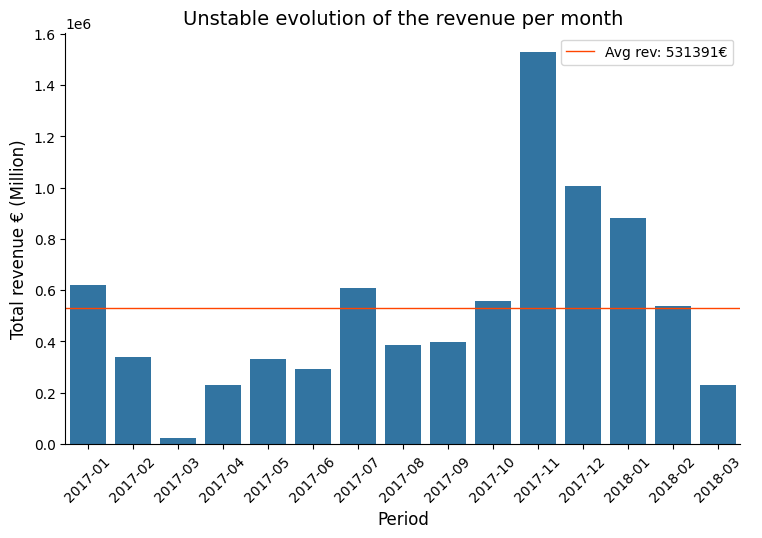

In [142]:
Rev_growth['created_date_str'] = Rev_growth['created_date'].dt.to_period('M').astype(str)

revenue_plot = sns.catplot(data=Rev_growth,
            kind='bar',
            x='created_date_str',
            y='total_paid',
            aspect=1.5
)

revenue_plot.ax.set_title('Unstable evolution of the revenue per month', fontsize=14)
revenue_plot.set_axis_labels('Period', 'Total revenue € (Million)', fontsize=12)
revenue_plot.ax.tick_params(axis='x', rotation=45)

mean_val = Rev_growth['total_paid'].mean()
revenue_plot.ax.axhline(mean_val, color='orangered', linestyle='-', linewidth=1, label=f'Avg rev: {mean_val:.0f}€')
revenue_plot.ax.legend(fontsize=10)

## Monthly order evolution

In [143]:
monthly_order = order_df.resample('ME',on='created_date')['order_id'].count().reset_index()

### Seaborn plotting

In [144]:
monthly_order

,created_date,order_id
0,2017-01-31,4593
1,2017-02-28,2043
2,2017-03-31,163
3,2017-04-30,1460
4,2017-05-31,1650
5,2017-06-30,1328
6,2017-07-31,3073
7,2017-08-31,2097
8,2017-09-30,1880
9,2017-10-31,2768


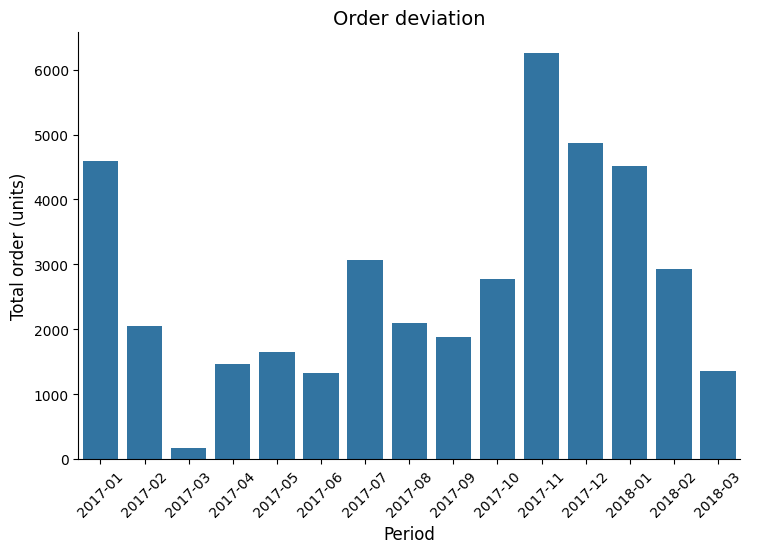

In [145]:
monthly_order['created_date_str'] = monthly_order['created_date'].dt.to_period('M').astype(str)

order_month_plot = sns.catplot(data=monthly_order,
            kind='bar',
            x='created_date_str',
            y='order_id',
            aspect=1.5
)

order_month_plot.ax.set_title('Order deviation', fontsize=14)
order_month_plot.set_axis_labels('Period', 'Total order (units)', fontsize=12)
order_month_plot.ax.tick_params(axis='x', rotation=45)

## Orders sold

In [146]:
# how many orders have more than 1 product?
(orderline_df.groupby('order_id')['sku'].count()>1).sum()

# 8571 orders have more than 2 products in the basket

np.int64(8571)

## Most items "sold"
In which quarter do we usually see peak

### Group by Quarter/Year

In [147]:
orderline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53210 entries, 0 to 53209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               53210 non-null  int64         
 1   order_id         53210 non-null  int64         
 2   quantity         53210 non-null  int64         
 3   sku              53210 non-null  object        
 4   unit_price       53210 non-null  float64       
 5   date             53210 non-null  datetime64[ns]
 6   unit_price_paid  53210 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 2.8+ MB


In [148]:
#order made
order_quarter = orderline_df.resample('QE',on='date')['quantity'].sum().reset_index()
order_quarter

,date,quantity
0,2017-03-31,10013
1,2017-06-30,6753
2,2017-09-30,10433
3,2017-12-31,20241
4,2018-03-31,12550


In [149]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40971 entries, 0 to 40970
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40971 non-null  int64         
 1   created_date  40971 non-null  datetime64[ns]
 2   total_paid    40971 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 960.4 KB


In [150]:
#revenue made quarterly
revenue_quarter = order_df.resample('QE',on='created_date')['total_paid'].sum().reset_index()
revenue_quarter

,created_date,total_paid
0,2017-03-31,984047.17
1,2017-06-30,855345.15
2,2017-09-30,1390462.06
3,2017-12-31,3093069.93
4,2018-03-31,1647939.60


In [151]:
#revenue made monthly
revenue_monthly = order_df.resample('ME',on='created_date')['total_paid'].sum().reset_index()
revenue_monthly

,created_date,total_paid
0,2017-01-31,618217.31
1,2017-02-28,340853.05
2,2017-03-31,24976.81
3,2017-04-30,230994.54
4,2017-05-31,332981.28
5,2017-06-30,291369.33
6,2017-07-31,608661.07
7,2017-08-31,385826.09
8,2017-09-30,395974.90
9,2017-10-31,558111.08


### Exploratory

In [152]:
revenue_quarter.plot(title = 'Revenue per quarter')

<Axes: title={'center': 'Revenue per quarter'}>

Error in callback <function _draw_all_if_interactive at 0x79bf7b0cd080> (for post_execute):


ValueError: Date ordinal 3246860.6265000002 converts to 10859-08-08T15:02:09.600032 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

ValueError: Date ordinal 3246860.6265000002 converts to 10859-08-08T15:02:09.600032 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

<Figure size 640x480 with 1 Axes>

## AOV column to be created

In [153]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40971 entries, 0 to 40970
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40971 non-null  int64         
 1   created_date  40971 non-null  datetime64[ns]
 2   total_paid    40971 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 960.4 KB


### Exploring dateframes:
* *week*
* *month*
* *quarter*

In [154]:
# AOV per week
aov_week = order_df.resample('W',on='created_date')['total_paid'].agg(['mean','median']).reset_index()
aov_week

,created_date,mean,median
0,2017-01-01,170.93,73.48
1,2017-01-08,126.72,65.99
2,2017-01-15,127.12,59.88
3,2017-01-22,136.73,73.09
4,2017-01-29,133.86,64.98
5,2017-02-05,163.90,79.97
6,2017-02-12,167.03,85.98
7,2017-02-19,173.57,83.88
8,2017-02-26,160.10,88.88
9,2017-03-05,115.34,82.14


In [155]:
# AOV per month
aov_month = order_df.resample('ME',on='created_date')['total_paid'].agg(['mean','median']).reset_index()
aov_month

,created_date,mean,median
0,2017-01-31,134.60,66.49
1,2017-02-28,166.84,83.98
2,2017-03-31,153.23,84.98
3,2017-04-30,158.22,78.97
4,2017-05-31,201.81,99.99
5,2017-06-30,219.40,106.98
6,2017-07-31,198.07,96.98
7,2017-08-31,183.99,99.99
8,2017-09-30,210.62,104.34
9,2017-10-31,201.63,103.57


In [156]:
# AOV per quarter
aov_quarter = order_df.resample('QE',on='created_date')['total_paid'].agg(['mean','median']).reset_index()
aov_quarter

,created_date,mean,median
0,2017-03-31,144.73,71.98
1,2017-06-30,192.73,94.99
2,2017-09-30,197.23,99.99
3,2017-12-31,222.67,119.97
4,2018-03-31,187.41,93.99


### Seaborn plotting

WEEKLY graph

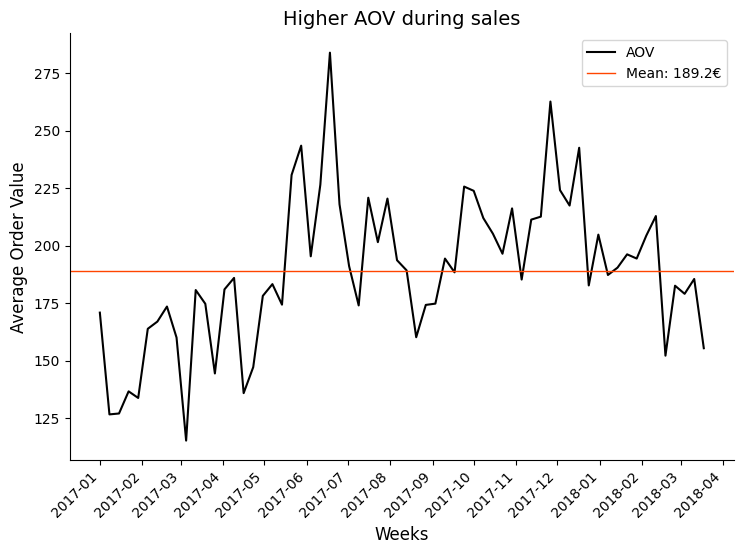

In [157]:
#weekly

weekly_aov_plot = sns.relplot(kind='line',
            data=aov_week,
            x='created_date',
            y='mean',
            label='AOV',
            color='black',
            height=5,
            aspect=1.5);

# Titles
weekly_aov_plot.ax.set_title('Higher AOV during sales', fontsize=14)

# Labels
weekly_aov_plot.set_axis_labels('Weeks', 'Average Order Value', fontsize=12)
weekly_aov_plot.ax.set_xticklabels(
    weekly_aov_plot.ax.get_xticklabels(1),
    fontsize=10, rotation=45, ha='right'
)

# Force every month to show
weekly_aov_plot.ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
weekly_aov_plot.ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotate labels
weekly_aov_plot.ax.tick_params(axis='x', rotation=45)


# Average reference line
mean_val = aov_week['mean'].mean()
weekly_aov_plot.ax.axhline(mean_val, color='orangered', linestyle='-', linewidth=1, label=f'Mean: {mean_val:.1f}€')

weekly_aov_plot.ax.legend(fontsize=10)

MONTHLY graph

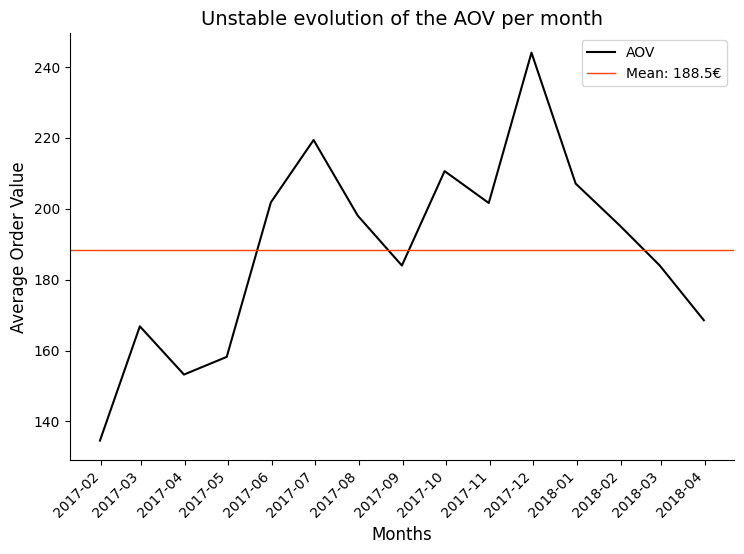

In [158]:
#monthly

sns_aov_mthly = sns.relplot(kind='line',
            data=aov_month,
            x='created_date',
            y='mean',
            label='AOV',
            color='black',
            height=5,
            aspect=1.5);

# Titles
sns_aov_mthly.ax.set_title('Unstable evolution of the AOV per month', fontsize=14)

# Labels
sns_aov_mthly.set_axis_labels('Months', 'Average Order Value', fontsize=12)
sns_aov_mthly.ax.set_xticklabels(
    sns_aov_mthly.ax.get_xticklabels(1),
    fontsize=10, rotation=45, ha='right'
)

# Force every month to show
sns_aov_mthly.ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
sns_aov_mthly.ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotate labels
sns_aov_mthly.ax.tick_params(axis='x', rotation=45)


# Average reference line
mean_val = aov_month['mean'].mean()
sns_aov_mthly.ax.axhline(mean_val, color='orangered', linestyle='-', linewidth=1, label=f'Mean: {mean_val:.1f}€')

sns_aov_mthly.ax.legend(fontsize=10)

QUARTERLY graph

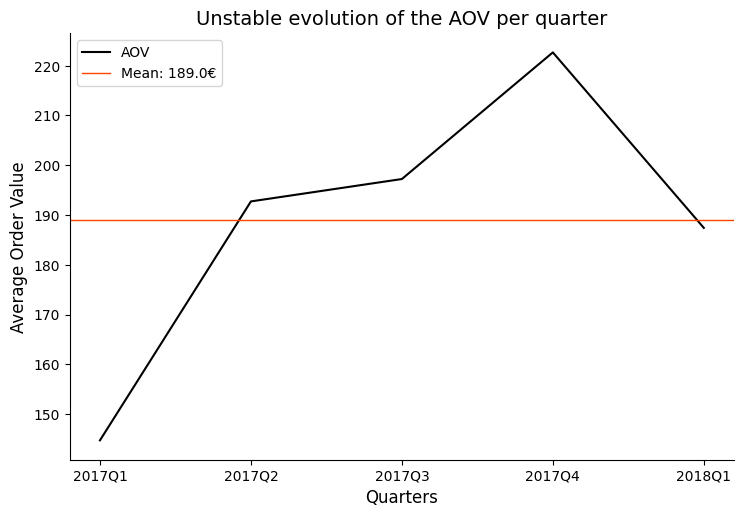

In [159]:
#quarterly

aov_quarter['created_date_str'] = aov_quarter['created_date'].dt.to_period('Q').astype(str)


sns_aov_qtly = sns.relplot(kind='line',
            data=aov_quarter,
            x='created_date_str',
            y='mean',
            label='AOV',
            color='black',
            height=5,
            aspect=1.5);

# Titles
sns_aov_qtly.ax.set_title('Unstable evolution of the AOV per quarter', fontsize=14)

# Labels
sns_aov_qtly.set_axis_labels('Quarters', 'Average Order Value', fontsize=12)

mean_val = aov_quarter['mean'].mean()
sns_aov_qtly.ax.axhline(mean_val, color='orangered', linestyle='-', linewidth=1, label=f'Mean: {mean_val:.1f}€')
sns_aov_qtly.ax.legend(fontsize=10)

## Average Basket Size

Let's find out if the AOV are connected to the size basket too.
Are the period correlated?

In [160]:
orderline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53210 entries, 0 to 53209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               53210 non-null  int64         
 1   order_id         53210 non-null  int64         
 2   quantity         53210 non-null  int64         
 3   sku              53210 non-null  object        
 4   unit_price       53210 non-null  float64       
 5   date             53210 non-null  datetime64[ns]
 6   unit_price_paid  53210 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 2.8+ MB


### Grouping per month

In [161]:
gp_basket = orderline_df.groupby(['date','order_id'])['quantity'].sum().reset_index()
gp_basket

,date,order_id,quantity
0,2017-01-01 01:46:16,299545,1
1,2017-01-01 01:50:34,299546,1
2,2017-01-01 01:54:11,295347,1
3,2017-01-01 02:20:14,299556,1
4,2017-01-01 02:38:50,299561,1
...,...,...,...
52935,2018-03-14 11:42:41,527035,1
52936,2018-03-14 11:49:01,527070,2
52937,2018-03-14 11:49:36,527074,2
52938,2018-03-14 11:54:35,527096,3


In [162]:
# resample per month
avg_bsk_month = gp_basket.resample('ME',on='date')['quantity'].mean().reset_index()
avg_bsk_month

,date,quantity
0,2017-01-31,1.14
1,2017-02-28,1.14
2,2017-03-31,1.12
3,2017-04-30,1.13
4,2017-05-31,1.20
5,2017-06-30,1.18
6,2017-07-31,1.13
7,2017-08-31,1.13
8,2017-09-30,1.13
9,2017-10-31,1.13


### Seaborn plotting

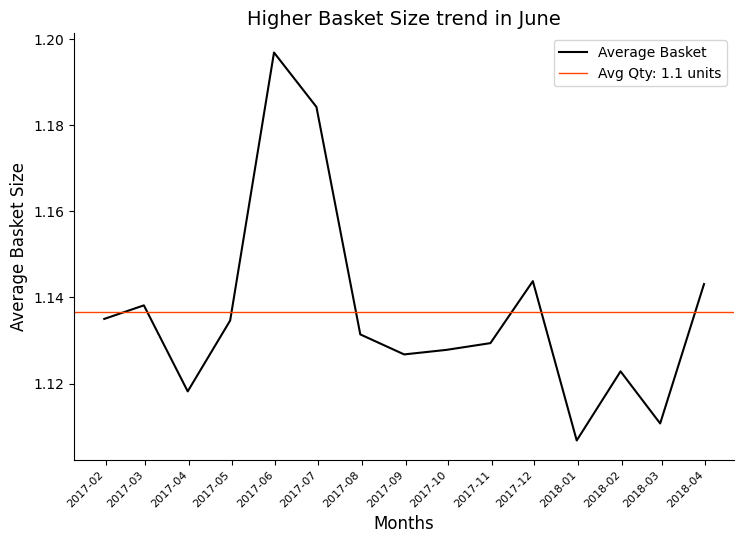

In [163]:
avg_basket_plot = sns.relplot(kind='line',data=avg_bsk_month,
            x='date',
            y='quantity',
            label='Average Basket',
            color='black',
            aspect=1.5)

# Titles
avg_basket_plot.ax.set_title('Higher Basket Size trend in June', fontsize=14)

# Labels
avg_basket_plot.set_axis_labels('Months', 'Average Basket Size', fontsize=12)
avg_basket_plot.ax.set_xticklabels(
    avg_basket_plot.ax.get_xticklabels(1),
    fontsize=8, rotation=45, ha='right'
)
# Force every month to show
avg_basket_plot.ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
avg_basket_plot.ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotate labels
avg_basket_plot.ax.tick_params(axis='x', rotation=45)


# Average reference line
mean_val = avg_bsk_month['quantity'].mean()
avg_basket_plot.ax.axhline(mean_val, color='orangered', linestyle='-', linewidth=1, label=f'Avg Qty: {mean_val:.1f} units')


#Legend
avg_basket_plot.ax.legend(fontsize=10)

In [164]:
orderline_df

,id,order_id,quantity,sku,unit_price,date,unit_price_paid
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19
3,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
4,1119145,299561,1,PEB0015,142.49,2017-01-01 02:38:50,142.49
...,...,...,...,...,...,...,...
53205,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,9.99
53206,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,19.98
53207,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,19.98
53208,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,29.97


## TOP Sellers Xmas period 11/17:1/18

In [165]:
top_xmas = orderline_df.loc[orderline_df['date'].between('2017-11-01', '2018-02-01')]

In [166]:
top_xmas

,id,order_id,quantity,sku,unit_price,date,unit_price_paid
27506,1394796,420583,1,OWC0194-4,374.99,2017-11-01 00:44:48,374.99
27507,1394804,420587,1,LIF0115,69.99,2017-11-01 01:01:24,69.99
27508,1394823,420591,1,APP1976,397.81,2017-11-01 02:21:34,397.81
27509,1394831,420498,1,CRU0052-2,182.99,2017-11-01 03:12:49,182.99
27510,1394835,420596,1,IFX0031,39.99,2017-11-01 04:39:40,39.99
...,...,...,...,...,...,...,...
47846,1593947,503440,1,ZAG0034,8.99,2018-01-31 23:55:51,8.99
47847,1593948,503441,1,WDT0318,249.99,2018-01-31 23:55:54,249.99
47848,1593956,503440,1,JMO0066,9.99,2018-01-31 23:57:00,9.99
47849,1593958,503440,1,MOX0019,3.71,2018-01-31 23:57:20,3.71


In [167]:
# who are making the most revenue top 10 sellers
top_xmas.groupby('sku').agg({'quantity':'sum','unit_price_paid':'sum'}).sort_values('unit_price_paid',ascending=False).head(10)

,quantity,unit_price_paid
sku,,
APP2477,84,66045.99
APP2485,65,57987.82
LGE0044,100,56177.34
APP2072,55,53646.06
APP1922,297,46248.71
APP2483,50,44604.12
APP2479,55,43338.89
APP2478,47,37018.32
AP20264,47,35661.37


In [168]:
top_10 = ['APP2477', 'APP2485', 'LGE0044', 'APP2072', 'APP1922',
            'APP2483', 'APP2479', 'APP2478', 'AP20264', 'WDT0183']

rev_ev = orderline_df[orderline_df['sku'].isin(top_10)]
rev_top_xmas = rev_ev.resample('ME',on='date')['unit_price_paid'].sum().reset_index()


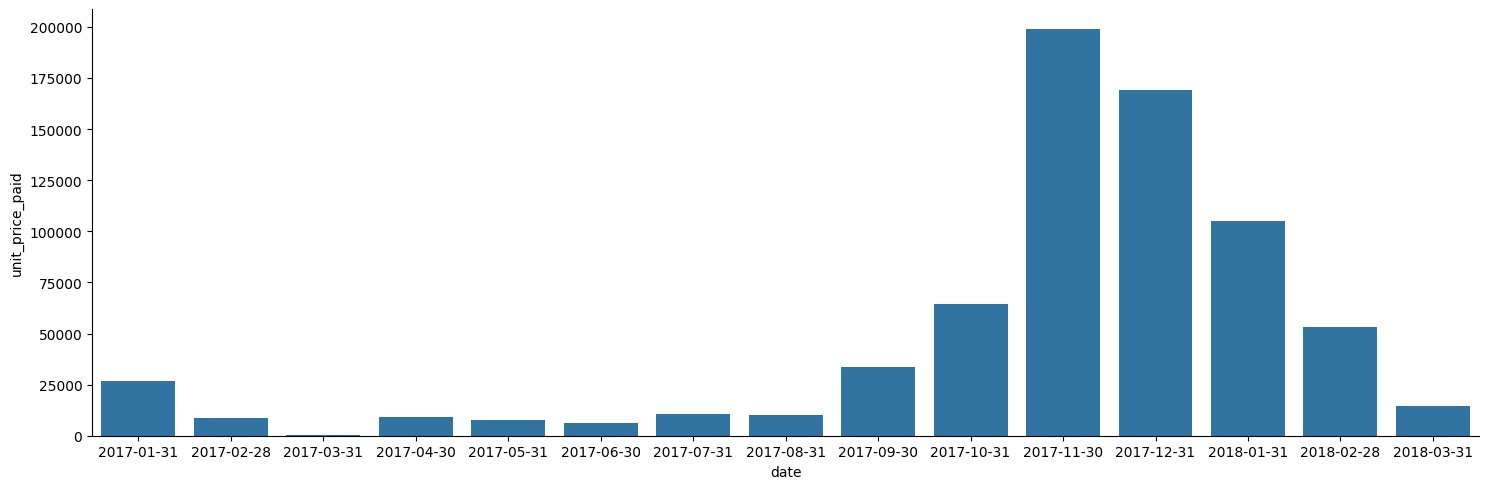

In [169]:
sns.catplot(data=rev_top_xmas,
            kind='bar',
            x='date',
            y='unit_price_paid',
            height=5,
            aspect=3

);

Top 10 sellers in quantity

In [170]:
#   APP1190	572	30364.36
#   APP1922	297	46248.71
#   WDT0183	246	32384.49
#   ZAG0032	200	7175.70
#   CRU0051	194	24312.56
#   APP0698	191	1808.59
#   PAC2477	171	3510.26
#   CRU0050	158	12779.79
#   APP0927	135	2464.98
#   NEA0020	128	9517.51


In [171]:
skus_list = ['APP1190', 'APP1922', 'WDT0183', 'ZAG0032', 'CRU0051',
            'APP0698', 'PAC2477', 'CRU0050', 'APP0927', 'NEA0020']

filter_df = orderline_df[orderline_df['sku'].isin(skus_list)]
top_rev_exp =  filter_df.resample('ME',on='date')['unit_price_paid'].sum().reset_index()
top_rev_exp

,date,unit_price_paid
0,2017-01-31,17138.90
1,2017-02-28,8000.20
2,2017-03-31,503.91
3,2017-04-30,4656.32
4,2017-05-31,6414.27
5,2017-06-30,2701.63
6,2017-07-31,11316.12
7,2017-08-31,11829.42
8,2017-09-30,11900.96
9,2017-10-31,33080.99


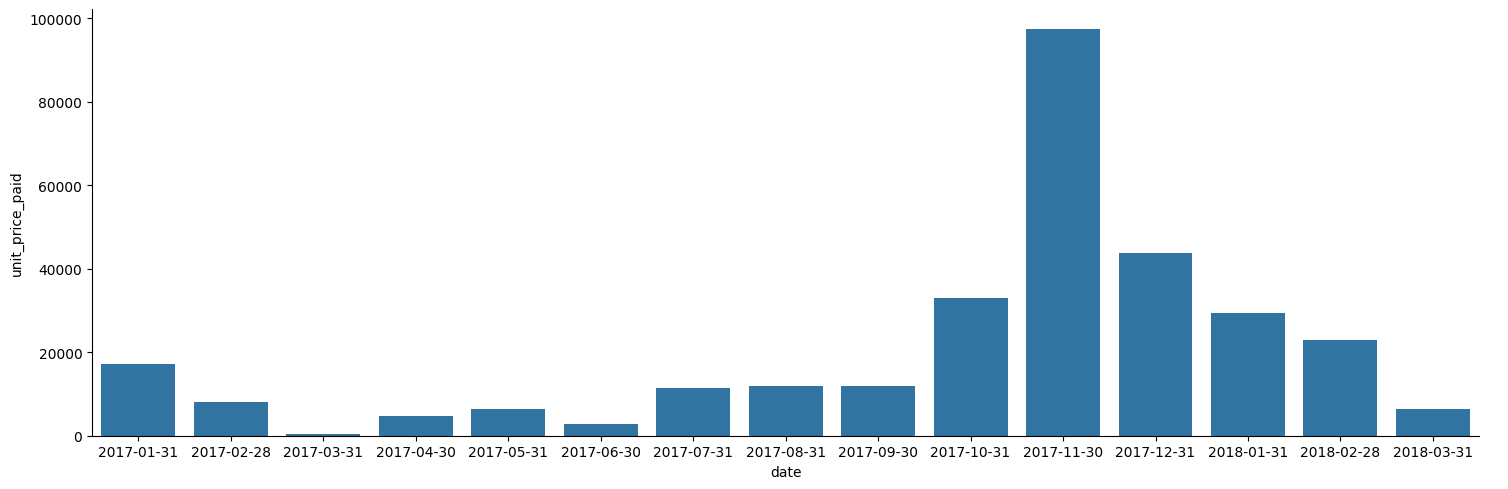

In [172]:
sns.catplot(data=top_rev_exp,
            kind='bar',
            x='date',
            y='unit_price_paid',
            height=5,
            aspect=3
);

In [173]:
filter_df

,id,order_id,quantity,sku,unit_price,date,unit_price_paid
19,1119325,299571,1,WDT0183,151.99,2017-01-01 12:00:57,151.99
20,1119326,299634,3,WDT0183,151.99,2017-01-01 12:01:01,455.97
58,1119728,299850,2,APP0698,14.99,2017-01-01 18:25:21,29.98
90,1120002,299984,1,APP0927,19.99,2017-01-01 21:10:46,19.99
169,1120584,300268,1,APP0927,19.99,2017-01-02 08:40:39,19.99
...,...,...,...,...,...,...,...
53205,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,9.99
53206,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,19.98
53207,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,19.98
53208,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,29.97


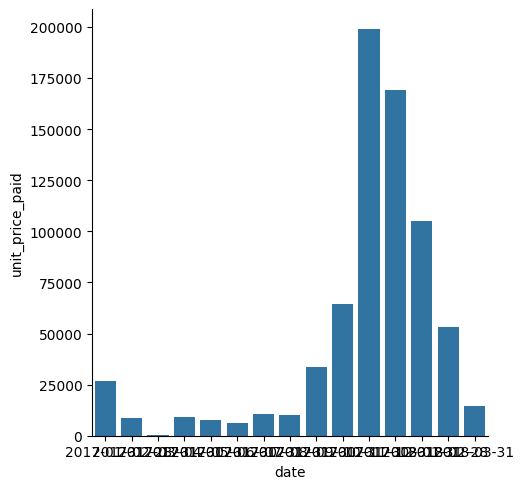

In [174]:
sns.catplot(data=rev_top_xmas,
            kind='bar',
            x='date',
            y='unit_price_paid'
);

Top 10 sellers in revenue

In [175]:
#    APP2477 : 84
#    APP2485 : 65
#    LGE0044 : 100
#    APP2072 : 55
#    APP1922 : 297
#    APP2483 : 50
#    APP2479 : 55
#    APP2478	: 47
#    AP20264 : 47
#    WDT0183 : 246

Type of products top revenue

In [176]:
sku_list = ['APP2477', 'APP2485', 'LGE0044', 'APP2072', 'APP1922',
            'APP2483', 'APP2479', 'APP2478', 'AP20264', 'WDT0183']

filtered_df = product_df[product_df['sku'].isin(sku_list)]
filtered_df


,sku,name,desc,price,type
139,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4TB (WD40EFRX).,169.00,12655397
5152,LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",99% Professional Monitor sRGB color calibrator cable USB-C connection for Mac and PC,599.00,1296
5442,APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384
7469,APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",laptop MacBook Air 13 inch i5 18GHz 8GB RAM and 128GB SSD,1105.59,"2,17E+11"
7903,AP20264,Like new - Apple iPhone 7 Plus 128GB RED,Refurbished iPhone 7 Plus Color RED Edition with 128GB capacity,889.00,85651716
8165,APP2477,Apple iPhone 64GB Space Gray 8,Apple iPhone 64GB 8 Color Space Gray,809.00,113291716
8166,APP2478,Apple iPhone 64GB Silver 8,Apple iPhone 64GB 8 Silver,809.00,113291716
8167,APP2479,Apple iPhone 64GB Gold 8,Apple iPhone 64GB 8 in Gold,809.00,113291716
8170,APP2483,Apple iPhone 8 Plus 64GB Space Gray,Apple iPhone 8 Plus 64GB Space Gray,919.00,113281716
8172,APP2485,Apple iPhone 8 Plus 64GB Gold,Apple iPhone 8 Plus 64GB Gold color,919.00,113281716


## TOP 5: sold products

### Group by counts

In [177]:
orderline_df.value_counts('sku').head(20)

# Top sellers accross :
# APP1190

,count
sku,
APP1190,866
APP1922,511
APP0698,478
APP0927,378
SAM0074,298
WDT0183,289
CRU0051,269
APP2446,260
APP1970,220


Topsellers Skus


* APP1190
* APP1922
* APP0698
* APP0927
* SAM0074
* WDT0183


### Average Price

Create mask for each SKUs

In [178]:
APP1190_mask = orderline_df['sku'] == 'APP1190'
APP1922_mask = orderline_df['sku'] == 'APP1922'
APP0698_mask = orderline_df['sku'] == 'APP0698'
APP0927_mask = orderline_df['sku'] == 'APP0927'
SAM0074_mask = orderline_df['sku'] == 'SAM0074'
WDT0183_mask = orderline_df['sku'] == 'WDT0183'

In [179]:
#create new DF
APP1190_plot = orderline_df.loc[APP1190_mask]
APP1922_plot = orderline_df.loc[APP1922_mask]
APP0698_plot = orderline_df.loc[APP0698_mask]
APP0927_plot = orderline_df.loc[APP0927_mask]
SAM0074_plot = orderline_df.loc[SAM0074_mask]
WDT0183_plot = orderline_df.loc[WDT0183_mask]

In [180]:
top_prod =orderline_df.loc[APP1190_mask|APP1922_mask|APP0698_mask|APP0927_mask|SAM0074_mask|WDT0183_mask]

In [181]:
top_prod

,id,order_id,quantity,sku,unit_price,date,unit_price_paid
19,1119325,299571,1,WDT0183,151.99,2017-01-01 12:00:57,151.99
20,1119326,299634,3,WDT0183,151.99,2017-01-01 12:01:01,455.97
58,1119728,299850,2,APP0698,14.99,2017-01-01 18:25:21,29.98
79,1119922,299944,1,SAM0074,153.89,2017-01-01 20:30:39,153.89
90,1120002,299984,1,APP0927,19.99,2017-01-01 21:10:46,19.99
...,...,...,...,...,...,...,...
53205,1649447,527035,1,APP0698,9.99,2018-03-14 11:42:41,9.99
53206,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,19.98
53207,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,19.98
53208,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,29.97


In [182]:
top_prod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2820 entries, 19 to 53209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               2820 non-null   int64         
 1   order_id         2820 non-null   int64         
 2   quantity         2820 non-null   int64         
 3   sku              2820 non-null   object        
 4   unit_price       2820 non-null   float64       
 5   date             2820 non-null   datetime64[ns]
 6   unit_price_paid  2820 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 176.2+ KB


In [183]:
top_prod.groupby('sku').agg({'unit_price':'mean','quantity':'sum'})

,unit_price,quantity
sku,,
APP0698,9.99,820
APP0927,17.16,489
APP1190,54.42,954
APP1922,161.11,537
SAM0074,152.55,329
WDT0183,137.98,476


Conclusion:
* Top seller products are usually in the low-medium price range

### Different pricing sold per SKU
Let's find:
* evolution of their discount
* evolution of their sales

In [184]:
# how many prices was it sold at : 17
APP1190_plot['unit_price'].nunique()

17

In [185]:
# how many prices was it sold at : 9

APP1922_plot['unit_price'].nunique()

9

In [186]:
# how many prices was it sold at : 7

APP0698_plot['unit_price'].nunique()

7

In [187]:
# how many prices was it sold at : 11

APP0927_plot['unit_price'].nunique()

11

In [188]:
# how many prices was it sold at : 40

SAM0074_plot['unit_price'].nunique()

40

In [189]:
# how many prices was it sold at : 28

WDT0183_plot['unit_price'].nunique()

28

### Unique price evolution

In [190]:
top_group = top_prod.drop_duplicates(subset=['date', 'sku', 'unit_price'])
top_graph = (top_group
    .set_index('date')
    .groupby('sku')
    .resample('ME')['unit_price']
    .apply(lambda x: x.unique())
    .explode()
    .reset_index()
)[['date', 'sku', 'unit_price']]
top_graph

,date,sku,unit_price
0,2017-01-31,APP0698,14.99
1,2017-01-31,APP0698,9.99
2,2017-01-31,APP0698,8.26
3,2017-02-28,APP0698,9.99
4,2017-02-28,APP0698,11.99
5,2017-03-31,APP0698,11.99
6,2017-04-30,APP0698,11.99
7,2017-04-30,APP0698,9.99
8,2017-05-31,APP0698,9.99
9,2017-06-30,APP0698,9.99


####Seaborn plotting
*Evolution of each SKU price*

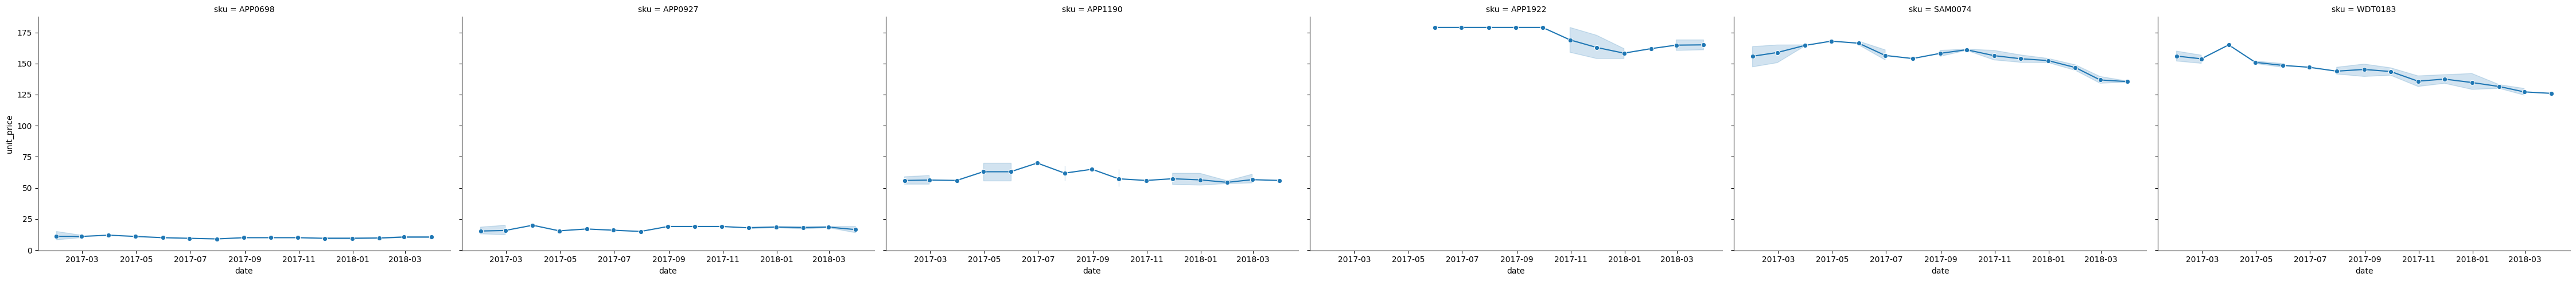

In [191]:
sns.relplot(kind='line',
            data=top_graph,
            x='date',
            marker='o',
            y='unit_price',
            col='sku',
            aspect=1.5);

### Sales evolution

In [192]:
top_quty = top_prod.groupby(['date','sku'])['quantity'].sum().reset_index()
top_quty

,date,sku,quantity
0,2017-01-01 12:00:57,WDT0183,1
1,2017-01-01 12:01:01,WDT0183,3
2,2017-01-01 18:25:21,APP0698,2
3,2017-01-01 20:30:39,SAM0074,1
4,2017-01-01 21:10:46,APP0927,1
...,...,...,...
2809,2018-03-14 11:42:41,APP0698,1
2810,2018-03-14 11:49:01,APP0698,2
2811,2018-03-14 11:49:36,APP0698,2
2812,2018-03-14 11:54:35,APP0698,3


In [193]:
top_quty = (top_prod
    .reset_index(drop=True)
    .groupby('sku')
    .resample('ME', on='date')['quantity']
    .sum()
    .reset_index()
)[['date', 'sku', 'quantity']]

top_quty

,date,sku,quantity
0,2017-01-31,APP0698,208
1,2017-02-28,APP0698,64
2,2017-03-31,APP0698,3
3,2017-04-30,APP0698,15
4,2017-05-31,APP0698,29
5,2017-06-30,APP0698,18
6,2017-07-31,APP0698,86
7,2017-08-31,APP0698,50
8,2017-09-30,APP0698,34
9,2017-10-31,APP0698,39


####Seaborn plotting

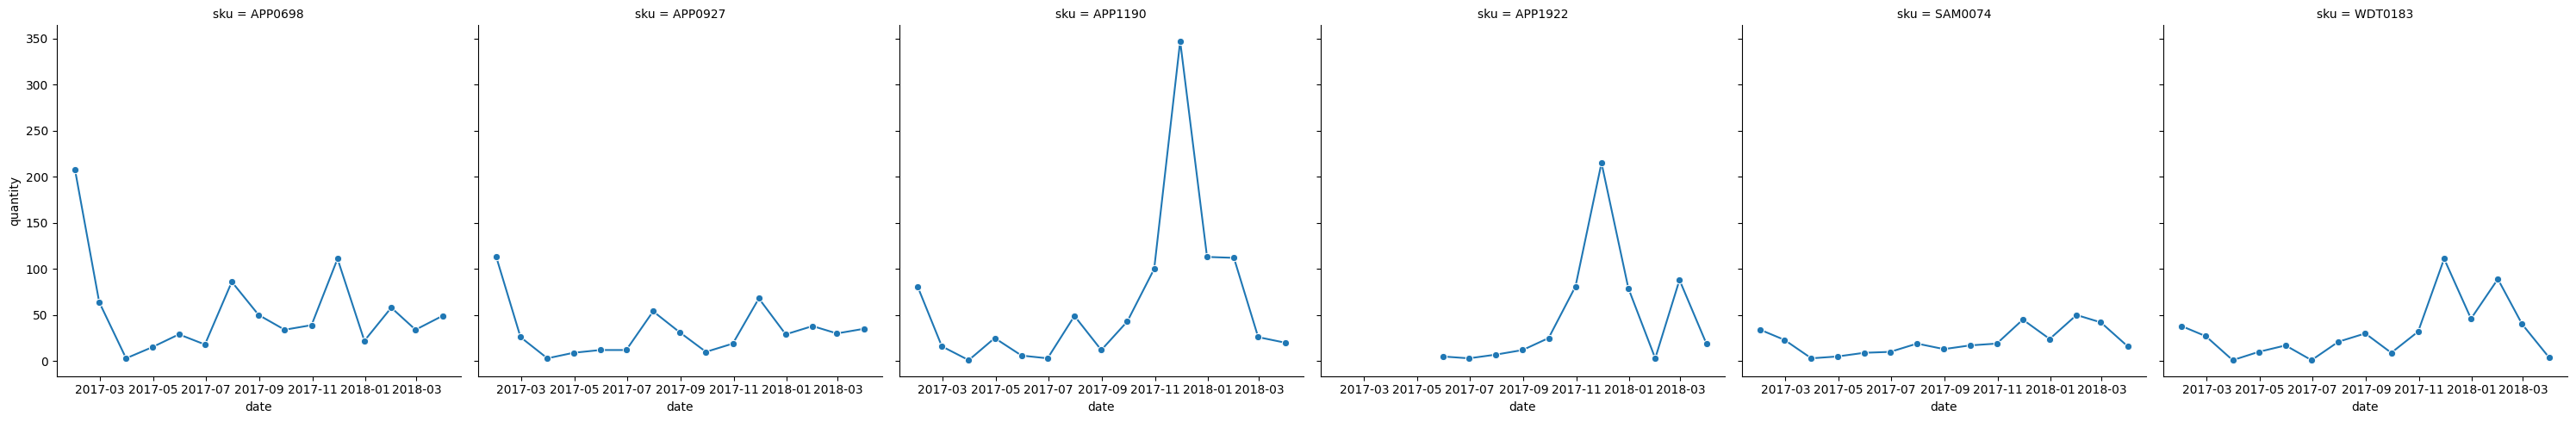

In [194]:
sns.relplot(kind='line',
            data=top_quty,
            x='date',
            y='quantity',
            marker='o',
            col='sku')

### What type of product they are

Filter in product_df via masks

In [195]:
APP1190_maskp = product_df['sku'] == 'APP1190'
APP1922_maskp = product_df['sku'] == 'APP1922'
APP0698_maskp = product_df['sku'] == 'APP0698'
APP0927_maskp = product_df['sku'] == 'APP0927'
SAM0074_maskp = product_df['sku'] == 'SAM0074'
WDT0183_maskp =product_df['sku'] == 'WDT0183'

In [196]:
product_df.loc[APP1190_maskp | APP1922_maskp | APP0698_maskp| APP0927_maskp | SAM0074_maskp |WDT0183_maskp ]

,sku,name,desc,price,type
139,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4TB (WD40EFRX).,169.00,12655397
622,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1230
1202,SAM0074,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA III with 3D V-NAND.,179.99,12215397
1425,APP0927,EarPods Apple Headphones with Remote and Mic (OEM),EarPods headphones Apple iPhone iPad and iPod with microphone and remote control,35.00,5384
2577,APP1190,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.,70.00,1231
5442,APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384


Finding:
* APP1190 : Apple Care OP: 70e
* APP1922 : Airpods OP: 179e
* APP0698 :	Apple USB Cable OP: 25e
* APP0927 : Apple headphones OP: 35e
* SAM0074 : hardrive OP: 179.99e
* WDT0183 : hardrive OP: 169e

Type is repeated twice with 2 Apple accessories
Products of interest from the customers

In [197]:
# only 125 unique type out of 9940 SKUs
product_df['type'].nunique()

125

#Categories

In [198]:
p_ol_df = product_df.merge(orderline_df,
                           on = 'sku',
                           how = 'inner')
p_ol_df.info()
# (53210, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53210 entries, 0 to 53209
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   sku              53210 non-null  object        
 1   name             53210 non-null  object        
 2   desc             53210 non-null  object        
 3   price            53210 non-null  float64       
 4   type             53210 non-null  object        
 5   id               53210 non-null  int64         
 6   order_id         53210 non-null  int64         
 7   quantity         53210 non-null  int64         
 8   unit_price       53210 non-null  float64       
 9   date             53210 non-null  datetime64[ns]
 10  unit_price_paid  53210 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(4)
memory usage: 4.5+ MB


## Categorize per price cat

In [199]:
p_ol_df ['price_cat'] = ''

### Function for pricing :**categories**

In [200]:
def categorize_price(price):
    if price <= 50: return 'Low price'
    if price <= 200: return 'Medium price'
    if price <= 400: return 'High price'
    return 'Premium price'

p_ol_df['price_cat'] = p_ol_df['unit_price'].apply(categorize_price)

In [201]:
p_ol_df

,sku,name,desc,price,type,id,order_id,quantity,unit_price,date,unit_price_paid,price_cat
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1121326,300551,1,54.99,2017-01-02 13:34:30,54.99,Medium price
1,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1149253,310820,1,49.99,2017-01-17 09:37:43,49.99,Low price
2,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1149773,311042,1,49.99,2017-01-17 15:55:39,49.99,Low price
3,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1181573,324568,1,54.99,2017-02-15 13:36:16,54.99,Medium price
4,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1188189,327565,1,54.99,2017-02-22 13:01:25,54.99,Medium price
...,...,...,...,...,...,...,...,...,...,...,...,...
53205,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1499671,464365,1,22.99,2017-12-16 14:38:57,22.99,Low price
53206,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1523146,475426,1,19.54,2017-12-28 20:24:02,19.54,Low price
53207,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1559235,490325,2,22.99,2018-01-13 23:08:33,45.98,Low price
53208,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1596455,496812,1,22.99,2018-02-02 14:23:53,22.99,Low price


In [202]:
p_ol_df.groupby('price_cat')['sku'].nunique()

,sku
price_cat,
High price,626
Low price,2494
Medium price,1577
Premium price,670


## Discounts

### New discount column

In [203]:
p_ol_df ['discount'] = round((1-(p_ol_df['unit_price']/p_ol_df['price']))*100)

In [204]:
p_ol_df

,sku,name,desc,price,type,id,order_id,quantity,unit_price,date,unit_price_paid,price_cat,discount
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1121326,300551,1,54.99,2017-01-02 13:34:30,54.99,Medium price,8.00
1,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1149253,310820,1,49.99,2017-01-17 09:37:43,49.99,Low price,17.00
2,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1149773,311042,1,49.99,2017-01-17 15:55:39,49.99,Low price,17.00
3,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1181573,324568,1,54.99,2017-02-15 13:36:16,54.99,Medium price,8.00
4,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,1188189,327565,1,54.99,2017-02-22 13:01:25,54.99,Medium price,8.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53205,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1499671,464365,1,22.99,2017-12-16 14:38:57,22.99,Low price,23.00
53206,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1523146,475426,1,19.54,2017-12-28 20:24:02,19.54,Low price,35.00
53207,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1559235,490325,2,22.99,2018-01-13 23:08:33,45.98,Low price,23.00
53208,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,1596455,496812,1,22.99,2018-02-02 14:23:53,22.99,Low price,23.00


### Evolution of discount type

In [205]:
p_ol_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53210 entries, 0 to 53209
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   sku              53210 non-null  object        
 1   name             53210 non-null  object        
 2   desc             53210 non-null  object        
 3   price            53210 non-null  float64       
 4   type             53210 non-null  object        
 5   id               53210 non-null  int64         
 6   order_id         53210 non-null  int64         
 7   quantity         53210 non-null  int64         
 8   unit_price       53210 non-null  float64       
 9   date             53210 non-null  datetime64[ns]
 10  unit_price_paid  53210 non-null  float64       
 11  price_cat        53210 non-null  object        
 12  discount         53210 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(5)
memory usage: 5.3+ MB


####Group by "Month End"

In [206]:
disc_avg = p_ol_df.resample('ME',on='date')['discount'].mean().reset_index()
disc_avg

,date,discount
0,2017-01-31,24.82
1,2017-02-28,19.62
2,2017-03-31,18.96
3,2017-04-30,18.29
4,2017-05-31,15.32
5,2017-06-30,17.41
6,2017-07-31,24.88
7,2017-08-31,20.53
8,2017-09-30,20.11
9,2017-10-31,21.98


#### Seaborn plotting

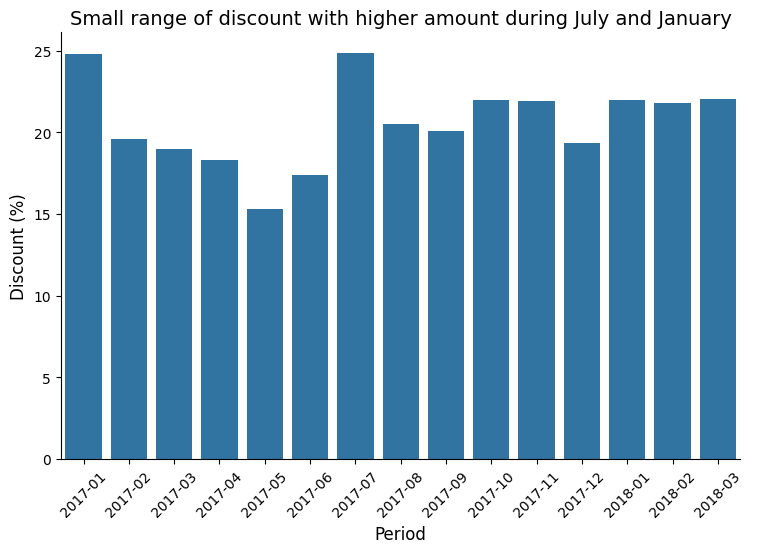

In [207]:
disc_avg['date_str'] = disc_avg['date'].dt.to_period('M').astype(str)

disc_plot_growth = sns.catplot(data=disc_avg,
            kind='bar',
            x='date_str',
            y='discount',
            aspect=1.5,
            height=5
)

disc_plot_growth.ax.set_title('Small range of discount with higher amount during July and January', fontsize=14)
disc_plot_growth.set_axis_labels('Period', 'Discount (%)', fontsize=12)
disc_plot_growth.ax.tick_params(axis='x', rotation=45)


### Categorize per discount cat

In [208]:
p_ol_df['disc_cat'] = ''

#### Function for discount categorization

In [209]:
def categorize_discount(discount):
    if discount == 0: return 'Full price'
    if discount <= 10: return 'Low discount'
    if discount <= 30: return 'Medium discount'
    if discount <= 60: return 'high discount'
    return 'outliers'

p_ol_df['disc_cat'] = p_ol_df['discount'].apply(categorize_discount)

In [210]:
p_ol_df['disc_cat'].sample(100)

,disc_cat
25622,Medium discount
16995,Low discount
2706,Medium discount
7036,Low discount
33505,Medium discount
21733,Medium discount
8193,Medium discount
18191,Low discount
17892,Medium discount
46772,Low discount


####Count of products per category

In [211]:
p_ol_df.groupby('disc_cat')['sku'].nunique()

,sku
disc_cat,
Full price,671
Low discount,1766
Medium discount,3175
high discount,1475
outliers,202


### Product type per discount

In [212]:
# create a mask for high discounts
high_disc_mask = p_ol_df['disc_cat'] == 'high discount'

####Group by discount category and Sku

In [213]:
# evolution of the discount per unique SKUs per quarter and year
plot_disc = p_ol_df.groupby('disc_cat')['sku'].count()

In [214]:
plot_disc

,sku
disc_cat,
Full price,3360
Low discount,12224
Medium discount,25906
high discount,9557
outliers,2163


What type of products are in the outliers

In [215]:
outliers_mask = p_ol_df['disc_cat'] == 'outliers'

In [216]:
p_ol_df.loc[outliers_mask].sample(100)
# outliers are not always odd values, some of them are possible
# product that is going to be discontinued
#

,sku,name,desc,price,type,id,order_id,quantity,unit_price,date,unit_price_paid,price_cat,discount,disc_cat
29186,LEX0037,Lexar JumpDrive USB 3.0 32GB Flash Drive P20,USB3.0 flash drive with speeds up to 400 MB / s read and 150 MB / s write for Mac and PC,68.90,57445397,1155344,313259,1,18.99,2017-01-22 18:43:04,18.99,Low price,72.00,outliers
5482,NTE0055,NewerTech NuGuard KX iPhone Case SE / 5s / 5 Black / Yellow,IPhone Case SE / 5s / 5 ultra resistant for extreme conditions.,60.99,11865403,1573654,493088,1,12.99,2018-01-22 10:41:36,12.99,Low price,79.00,outliers
51769,PAC2477,Pack of 2 units Zagg Coda Wireless Headsets Black,Pack 2 Bluetooth wireless headset with autonomous 10 hours of music for iPhone iPad and iPod,59.98,5384,1510890,469500,1,19.99,2017-12-22 11:18:13,19.99,Low price,67.00,outliers
4791,NTE0046,NewerTech NuGuard KX iPhone Case SE / 5s / 5 White,IPhone Case SE / 5s / 5 ultra resistant for extreme conditions.,60.99,11865403,1309622,385357,1,19.99,2017-08-02 12:08:47,19.99,Low price,67.00,outliers
51569,LIF0154,LifeProof nüüd iPhone 6s Black Waterproof Case,waterproof case (submersible 2m) 360 degree protection for iPhone 6s,89.99,11865403,1618060,513443,1,32.99,2018-02-17 18:26:07,32.99,Low price,63.00,outliers
38514,JAW0042-A,Open - Jawbone UP2 Black Rope Activity Monitor,Bluetooth activity monitor that records movements and sleep with personal trainer app for iPhone...,119.99,1298,1184508,325837,1,24.20,2017-02-18 00:15:42,24.20,Low price,80.00,outliers
41367,GRT0464,Griffin Survivor iPhone Case Journey 8 Plus / 7 Plus / 6s Plus / 6 Plus Turquoise / White,Resistive dispersion system impacts iPhone Case Plus models,29.99,11865403,1383103,415003,2,4.49,2017-10-20 11:24:27,8.98,Low price,85.00,outliers
42268,PAC2071,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD",Computer Refurbished iMac 24 inch Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD,1799.00,1282,1265635,364414,1,489.00,2017-06-11 12:34:44,489.00,Premium price,73.00,outliers
25847,OTT0132,OtterBox Symmetry Alpha Glass Case + Screen Protector + Program 1 M ± or guarantee for iPhone 6 ...,Pack OtterBox Symmetry Case + Screen Protector + 1 M ± or warranty Black iPhone 6S,49.99,11865403,1227237,345782,1,16.99,2017-04-12 17:20:45,16.99,Low price,66.00,outliers
6924,GRT0315,Griffin Survivor Case All-Terrain iPad mini 1/2/3 Black / Blue,An ultra resistant with 360 degree protection for cases mini extreme conditions 1 2 and 3,49.99,12635403,1226737,345552,1,9.99,2017-04-12 08:51:20,9.99,Low price,80.00,outliers


In [217]:
p_ol_df['discount'].describe()
#too many too big outliers

,discount
count,53210.00
mean,21.38
std,18.13
min,-212.00
25%,9.00
50%,18.00
75%,29.00
max,97.00


### Discounted

In [218]:
no_discount_mask = p_ol_df ['discount'] == 0
no_outliers_discount_mask = p_ol_df ['discount'] < 0

In [219]:
# count unique SKU with discount > 0
p_ol_df.loc[~no_discount_mask & ~ no_outliers_discount_mask,:].nunique()
# 4871

,0
sku,4871
name,4832
desc,3608
price,1003
type,114
id,49007
order_id,38324
quantity,26
unit_price,4198
date,48678


#### Outliers boxplot

<Axes: >

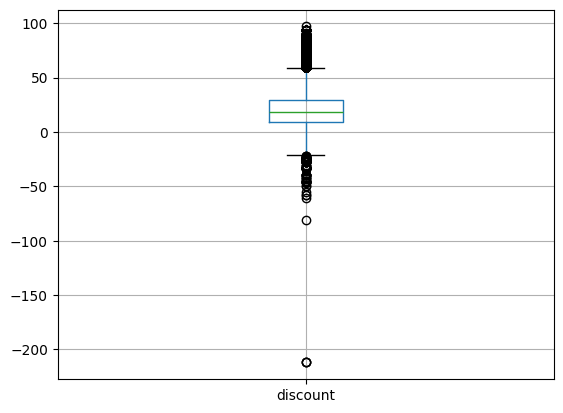

In [220]:
p_ol_df.boxplot('discount')

### Not discounted

In [221]:
p_ol_df.loc[p_ol_df ['discount'] == 0].nunique()
# 3139  unique orders are without discount
p_ord_no_discount = p_ol_df.loc[p_ol_df ['discount'] == 0]

#### Resampled by "Quarter End"

In [222]:
#unique order count per quarter without discount
# increasing trend
p_ord_no_discount.resample('QE',on='date')['order_id'].nunique().reset_index()

,date,order_id
0,2017-03-31,566
1,2017-06-30,535
2,2017-09-30,608
3,2017-12-31,696
4,2018-03-31,734


In [223]:
#revenue per quarter without discount
histo_no_discount = p_ord_no_discount.resample('QE',on='date')['unit_price_paid'].sum().reset_index()
histo_no_discount

,date,unit_price_paid
0,2017-03-31,55975.75
1,2017-06-30,74669.99
2,2017-09-30,99844.01
3,2017-12-31,140084.69
4,2018-03-31,84276.09


####Plot


<Axes: >

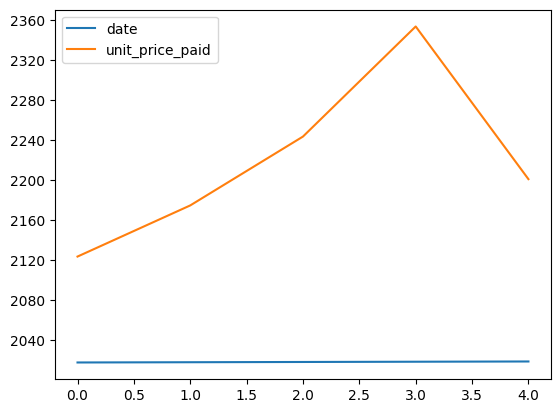

In [224]:
histo_no_discount.plot()

Which product are without discount

In [225]:
p_ord_no_discount['unit_price'].describe()
# min 2.99
# max 999
# Q3 = 119.99

,unit_price
count,3360.00
mean,126.12
std,186.19
min,2.99
25%,24.99
50%,49.99
75%,119.99
max,999.00


In [226]:
p_ord_no_discount.resample('QE',on='date')['unit_price'].sum().reset_index()

,date,unit_price
0,2017-03-31,53111.37
1,2017-06-30,70834.51
2,2017-09-30,91611.98
3,2017-12-31,132394.56
4,2018-03-31,75819.81


In [227]:
# to use regex
import re

In [228]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9940 entries, 0 to 9939
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sku     9940 non-null   object 
 1   name    9940 non-null   object 
 2   desc    9940 non-null   object 
 3   price   9940 non-null   float64
 4   type    9940 non-null   object 
dtypes: float64(1), object(4)
memory usage: 388.4+ KB


***Copy creation for category per product***

In [229]:
product_df_cat = product_df.copy()

In [230]:
product_df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9940 entries, 0 to 9939
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sku     9940 non-null   object 
 1   name    9940 non-null   object 
 2   desc    9940 non-null   object 
 3   price   9940 non-null   float64
 4   type    9940 non-null   object 
dtypes: float64(1), object(4)
memory usage: 388.4+ KB


## **TOP 10 most sold SKUs**


In [231]:
orderline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53210 entries, 0 to 53209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               53210 non-null  int64         
 1   order_id         53210 non-null  int64         
 2   quantity         53210 non-null  int64         
 3   sku              53210 non-null  object        
 4   unit_price       53210 non-null  float64       
 5   date             53210 non-null  datetime64[ns]
 6   unit_price_paid  53210 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 2.8+ MB


In [232]:
orderline_df.groupby('sku')['quantity'].sum().sort_values(ascending=False).head(10)

,quantity
sku,
APP1190,954
APP0698,820
APP1922,537
APP0927,489
WDT0183,476
SAM0074,329
CRU0051,328
APP2446,270
NTE0013,252


In [233]:
#APP1190
#APP0698
#APP1922
#APP2477
#WDT0183
#SAM0074
#CRU0051
#APP2446
#NTE0013
#CRU0050

### Boolean masks of the TOP SKUs

In [234]:
APP1190_mask = product_df_cat['sku'] == 'APP1190'
APP0698_mask = product_df_cat['sku'] == 'APP0698'
APP1922_mask = product_df_cat['sku'] == 'APP1922'
APP2477_mask = product_df_cat['sku'] == 'APP2477'
WDT0183_mask = product_df_cat['sku'] == 'WDT0183'
SAM0074_mask = product_df_cat['sku'] == 'SAM0074'
CRU0051_mask = product_df_cat['sku'] == 'CRU0051'
APP2446_mask = product_df_cat['sku'] == 'APP2446'
NTE0013_mask = product_df_cat['sku'] == 'NTE0013'
CRU0050_mask = product_df_cat['sku'] == 'CRU0050'

### Filter

In [235]:
product_df_cat.loc[APP0698_mask | APP1190_mask | WDT0183_mask |APP2446_mask |APP1922_mask |APP2477_mask | CRU0050_mask | CRU0051_mask |SAM0074_mask | NTE0013_mask ]

,sku,name,desc,price,type
139,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4TB (WD40EFRX).,169.00,12655397
150,NTE0013,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",Adapter HDD / SSD 2.5 SATA 3.5 compatible with Mac Pro.,26.99,12755395
622,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1230
1202,SAM0074,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA III with 3D V-NAND.,179.99,12215397
2577,APP1190,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.,70.00,1231
4841,CRU0051,Crucial MX300 525GB SSD Disk,SSD 525GB SATA Hard Disk 3.0 (6Gb / s) for Mac and PC,158.66,12215397
5442,APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384
6243,CRU0050,Crucial MX300 275GB SSD Disk,SSD 275GB SATA Hard Disk 3.0 (6Gb / s) for Mac and PC,98.39,12215397
7947,APP2446,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray,449.33,21561716
8165,APP2477,Apple iPhone 64GB Space Gray 8,Apple iPhone 64GB 8 Color Space Gray,809.00,113291716


In [236]:
#APP1190 : Iphone Care
#APP0698 : Apple USB
#APP1922 : Apple Airpods
#APP2477 : Iphone
#WDT0183 : Hard Drive
#SAM0074 : Hard Drive
#CRU0051 : Hard Disk
#APP2446 : Iphone
#NTE0013 : Adapter
#CRU0050 : Hard Disk

## Category per product

###New product category column

In [237]:
product_df_cat ['category'] = ''

### Category = Iphone
Filter 'iphone' & 'GB'

In [238]:
iphone_search = product_df_cat["name"].str.contains('iphone', case=False)
GB_search = product_df_cat["name"].str.contains('GB', case=False)
product_df_cat.loc[iphone_search & GB_search]

,sku,name,desc,price,type,category
342,TWS0040,Twelve South PlugBug World Dual Charger iPhone and iPad MacBook,dual charger for MacBook MagSafe and USB for iPhone and iPad.,49.99,13005399,
822,MOP0056,Mophie Space Pack Battery Case (1700mAh) and Storage 16GB iPhone SE / 5s / 5 Black,Housing with battery and 16GB external storage extras for iPhone SE / 5s / 5,149.99,"5,49E+11",
2551,APP1174,Apple iPhone 6s 128GB Silver,New Free iPhone 6s 128GB.,639.00,24821716,
2552,APP1175,Apple iPhone 6s 128GB Space Gray,New Free iPhone 6s 128GB.,639.00,24821716,
2553,APP1176,Apple iPhone 6s 128GB Gold,New Free iPhone 6s 128GB.,639.00,24821716,
2554,APP1177,Apple iPhone 6s 128GB Rose Gold,New Free iPhone 6s 128GB.,639.00,24821716,
3829,APP1481,Apple iPhone 64GB Space Gray,New iPhone SE with 4-inch screen 64 free GB.,549.00,51601716,
3830,APP1484,Apple iPhone 64GB Rose Gold,New iPhone SE with 4-inch screen 64 free GB.,549.00,51601716,
4137,MOP0077,Mophie Space Pack Battery Case (1700mAh) and Storage 32GB iPhone SE / 5s / 5 Gold,Case battery and 32GB for iPhone SE / 5s / 5,179.00,"5,49E+11",
5085,APP1645,Apple iPhone 7 32GB Silver,New Apple iPhone 32GB Free Silver 7,639.00,85641716,


###Types with the most SKUs

In [239]:
product_df_cat.groupby('type')['sku'].count().sort_values(ascending=False).head(10)

,sku
type,
11865403,1057
12175397,938
1298,781
11935397,562
11905404,453
1282,373
12635403,362
13835403,269
"5,74E+15",247


In [240]:
# Accessories = case
#count = 1057
product_df_cat.loc[product_df_cat['type'] == '11865403'].count()

,0
sku,1057
name,1057
desc,1057
price,1057
type,1057
category,1057


In [241]:
product_df_cat.loc[product_df_cat['type'] == '12175397'].count()
# count = 938
# Redundant SKU pattern
# additional type : 1298

,0
sku,938
name,938
desc,938
price,938
type,938
category,938


In [242]:
product_df_cat.loc[product_df_cat['type'] == '1298']
#count = 781
#describe = 5.99 to 3799e
# 75% = 199.99e

,sku,name,desc,price,type,category
451,BEL0127-A,Open - Belkin MIXIT Lightning iPhone Support,Loading dock + support synchronization with Lightning connection and USB cable for iPhone 7 / SE...,34.99,1298,
1058,SEA0043-A,"Open - Seagate Barracuda 1TB 35 ""SATA 7200rpm hard drive Mac and PC",internal hard drive for Mac and PC Refurbished 1TB (ST1000DM003),59.00,1298,
1431,WDT0175-A,"Open - Western Digital 2TB Green 35 ""5400rpm hard drive Mac and PC",WD Internal Hard Drive 2TB Mac and PC.,90.00,1298,
1485,NTE0056-A,"Open - NewerTech NuPower Battery 65W MacBook Pro 13 ""2009/14",MacBook Pro 13 inch Battery 2009/14,131.99,1298,
1497,BNQ0018-A,"(Open) LED Monitor BenQ VW2235H 215 """,Monitor 215 inch high range.,163.00,1298,
1498,DRO0018-A,(Open) Drobo Drobo 4-bay DAS RAID Array,Mac and PC RAID 4 bay with USB 3.0.,340.00,1298,
1499,GTE0012-A,(Open) G-Tech G-DRIVE USB 3.0 Hard Disk 2TB,external hard drive G-Technology for Mac or PC USB 3.0 2TB.,235.00,1298,
1500,NTE0014-A,"(Open) Battery NewerTech NuPower MacBook Pro 15 ""(2008-2009)",MacBook Pro 15 inch Battery,114.99,1298,
1501,OLL0012-A,(Open) Olloclip 4-in-1 lens iPhone July 8 6s 6 and 7 August 6s 6 Plus Silver / Black,Wide angle fisheye macro macro x10 and x15 for iPhone 6/6 Plus.,79.99,1298,
1502,OWC0101-A,Open - OWC 128GB PATA ZIF SSD MacBook Air 2008,128GB SSD for MacBook Air 2008.,362.99,1298,


In [243]:
product_df_cat.loc[product_df_cat['type'] == '12175397'].describe()
#describe
#min = 91.99
#max= 5894.49
# mean = 1204

,price
count,938.00
mean,1204.09
std,840.43
min,91.99
25%,630.00
50%,1007.97
75%,1537.06
max,5894.49


In [244]:
product_df_cat.loc[product_df_cat["name"].str.contains('hard drive', case=False)].count()
#count = 335 Hard drive category

,0
sku,335
name,335
desc,335
price,335
type,335
category,335


We notice repetitive type of categories:
- smartphone
- laptop

## Product categories function

In [245]:
import re

def categorize_product(row):
    name = str(row['name']).lower()
    desc = str(row['desc']).lower()
    text = name + ' ' + desc
    price = float(row['price'])



    # 1. iPhones
    if re.search(r'iphone', name) and price > 300:
        return "iPhone"
    # 2. laptop_desktop_tablet
    if re.search(r'ipad', name) and price > 250:
        return "laptop_desktop_tablet"
    # 2. laptop_desktop_tablet
    if re.search(r'macbook', name) and price > 700:
        return "laptop_desktop_tablet"
    # 2. laptop_desktop_tablet
    if re.search(r'imac|mac mini|mac pro', name) and price > 400:
        return "laptop_desktop_tablet"
    # 3. servers
    if re.search(r'synology|qnap|rackstation', name):
        return "servers"
    if re.search(r'\bnas\b', name) and price > 200:
        return "servers"
    # 4. storage
    if re.search(r'raid|thunderbay|pegasus|g.?speed|my passport|my book'
                r'|g.?drive|lacie|seagate backup|external.{0,20}(drive|disk)', text):
        return "storage"
    if re.search(r'\bssd\b|\bhdd\b|hard drive|solid state', name) and \
        not re.search(r'case|enclosure|repair|kit', name):
        return "storage"
    if re.search(r'\bdimm\b|so-dimm|ddr[234]|mac memory|owc memory|fcm memory'
                r'|crucial.{0,10}memory|kingston.{0,10}memory|\d+gb.{0,10}ddr', name):
        return "storage"
    # 4. monitors
    if re.search(r'\bmonitor\b|benq|\bdell\b.{0,20}\d+["\']|lg\s+\d+[a-z]|eizo', name):
        return "monitor"
    # 5. audio
    if re.search(r'speaker|headphone|headset|earphone|earbud|microphone'
                r'|bose|beats|jabra|jbl|soundlink|soundtouch', text):
        return "audio"
    # 6. Phone accessories (iPhone/iPod related, low price)
    if re.search(r'iphone|ipod|lightning', text) and price < 300:
        return "phone_accessory"
    # 7. Computer accessories (Mac/iPad related, low price)
    if re.search(r'ipad|macbook|imac|mac mini|mac pro|\bmac\b', text) and price < 700:
        if re.search(r'case|cover|sleeve|stand|hub|adapter|cable|charger|keyboard|dock', text):
            return "computer accessory"

    # 8. Fallback
    return "other"
product_df['category'] = product_df.apply(categorize_product, axis=1)

In [246]:
product_df

,sku,name,desc,price,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,computer accessory
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,13855401,computer accessory
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,1387,computer accessory
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,1230,phone_accessory
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pro (2006/07/08).,34.99,1364,storage
...,...,...,...,...,...,...
9935,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horizontally for Apple Watch,29.99,12282,other
9936,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartments MacBook up to 13 inches up to 10 inches Cases,69.95,1392,computer accessory
9937,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartments MacBook up to 13 inches up to 10 inches Cases,69.95,1392,computer accessory
9938,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartments MacBook up to 13 inches up to 10 inches Cases,69.95,1392,computer accessory


### Total sold per each category

In [247]:
prod_ol_df = product_df.merge(orderline_df,
                 on='sku',
                 how='inner')

In [248]:
prod_ol_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53210 entries, 0 to 53209
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   sku              53210 non-null  object        
 1   name             53210 non-null  object        
 2   desc             53210 non-null  object        
 3   price            53210 non-null  float64       
 4   type             53210 non-null  object        
 5   category         53210 non-null  object        
 6   id               53210 non-null  int64         
 7   order_id         53210 non-null  int64         
 8   quantity         53210 non-null  int64         
 9   unit_price       53210 non-null  float64       
 10  date             53210 non-null  datetime64[ns]
 11  unit_price_paid  53210 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(5)
memory usage: 4.9+ MB


In [249]:
product_categories = prod_ol_df.groupby('category').agg({'quantity':'sum'}).sort_values('quantity')
product_categories

,quantity
category,
laptop_desktop_tablet,1100
servers,1838
monitor,2106
iPhone,2333
audio,3703
computer accessory,7373
storage,12103
other,13750
phone_accessory,15684


###Plot: Bar chart

<Axes: xlabel='category'>

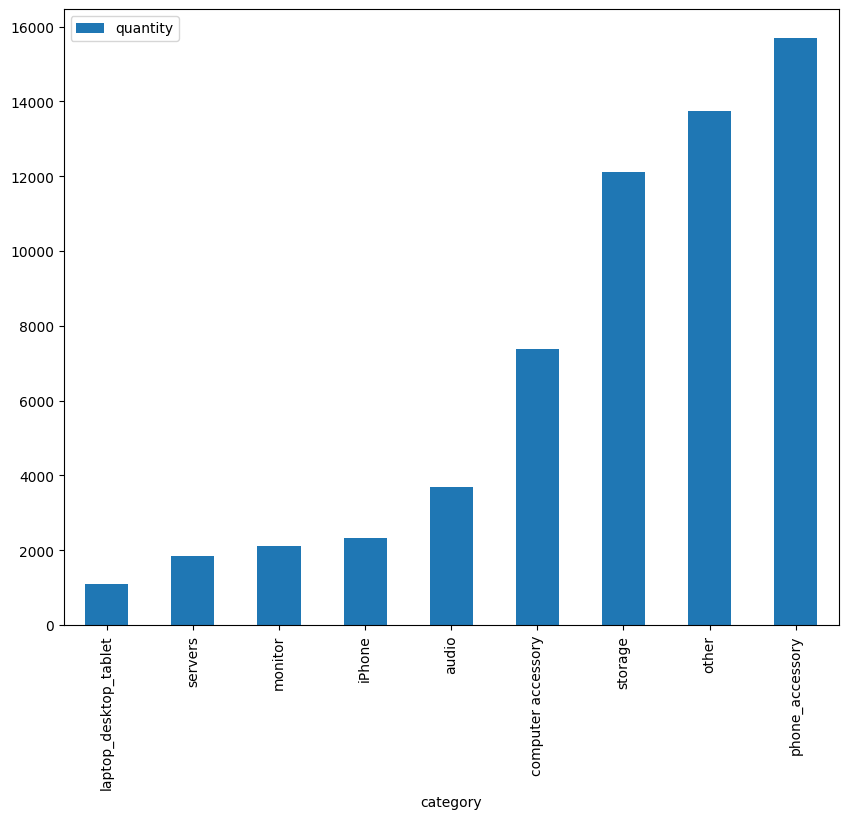

In [250]:
product_categories.plot.bar(figsize=(10,8))

##Groupby category for the quantity ordered

In [257]:
prod_ol_df

,sku,name,desc,price,type,category,id,order_id,quantity,unit_price,date,unit_price_paid,quarter,year
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,computer accessory,1121326,300551,1,54.99,2017-01-02 13:34:30,54.99,1,2017
1,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,computer accessory,1149253,310820,1,49.99,2017-01-17 09:37:43,49.99,1,2017
2,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,computer accessory,1149773,311042,1,49.99,2017-01-17 15:55:39,49.99,1,2017
3,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,computer accessory,1181573,324568,1,54.99,2017-02-15 13:36:16,54.99,1,2017
4,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,computer accessory,1188189,327565,1,54.99,2017-02-22 13:01:25,54.99,1,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53205,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,computer accessory,1499671,464365,1,22.99,2017-12-16 14:38:57,22.99,4,2017
53206,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,computer accessory,1523146,475426,1,19.54,2017-12-28 20:24:02,19.54,4,2017
53207,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,computer accessory,1559235,490325,2,22.99,2018-01-13 23:08:33,45.98,1,2018
53208,MMW0015,"My MW Case MacBook Pro 13 ""(Late 2016) Gray",Avoid shock and damage to your MacBook Pro 13-inch end of 2016 thanks to the foam LRPu,29.99,13835403,computer accessory,1596455,496812,1,22.99,2018-02-02 14:23:53,22.99,1,2018


In [276]:
year_cat = prod_ol_df.groupby('category')['quantity'].sum().sort_values(ascending=False).reset_index()
year_cat

,category,quantity
0,phone_accessory,15684
1,other,13750
2,storage,12103
3,computer accessory,7373
4,audio,3703
5,iPhone,2333
6,monitor,2106
7,servers,1838
8,laptop_desktop_tablet,1100


Top sellers categories:
- phone_accessory
- others
- storage

###Plot

<Axes: xlabel='category'>

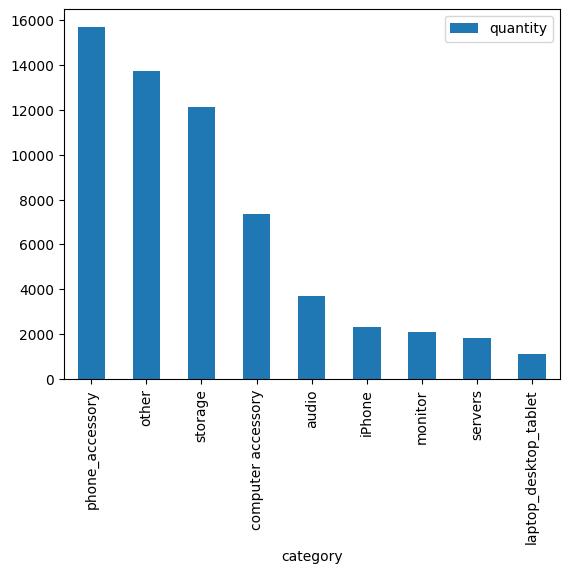

In [281]:
year_cat.plot.bar(x='category',
              y='quantity')

## Category discount evolution

In [282]:
#Let's create columns : Discount and discount_type
prod_ol_df ['discount'] = round((1-(p_ol_df['unit_price']/p_ol_df['price']))*100)
prod_ol_df['disc_cat'] = ''

### Function for discount

In [283]:
def categorize_discount(discount):
    if discount <= 10: return 'Low discount'
    if discount <= 30: return 'Medium discount'
    if discount <= 60: return 'high discount'
    return 'outliers'

prod_ol_df['disc_cat'] = prod_ol_df['discount'].apply(categorize_discount)

In [292]:
disc_cat_count = prod_ol_df.groupby('disc_cat')['sku'].count()

###Plot

<Axes: title={'center': 'Count of sku per discount'}, xlabel='disc_cat'>

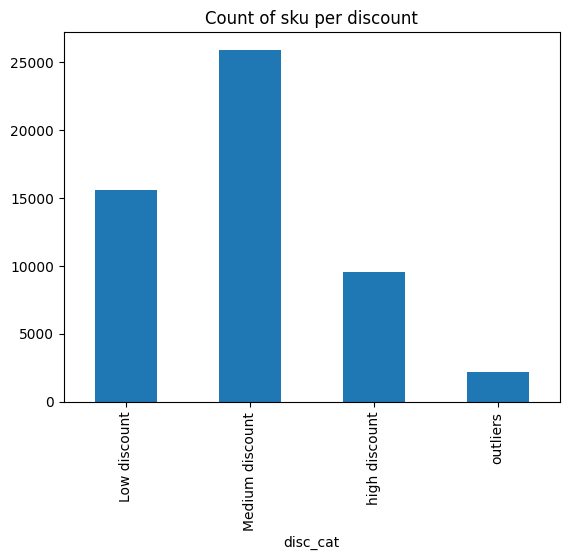

In [298]:
disc_cat_count.plot.bar(title='Count of sku per discount',
                        )